<a href="https://colab.research.google.com/github/A1r1p1it/fashion-mnist-pytorch/blob/main/Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FASHION MNIST

## 1. Setup & Imports


In [7]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

Device Agnostic code

In [8]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

Device: cuda


## 2. Loading the Data


In [9]:
# Training data
training_data = datasets.FashionMNIST(root = 'Dataset',
                                      train = True,
                                      transform = transforms.ToTensor(),
                                      download = True
                                      )

# Testing data
testing_data = datasets.FashionMNIST(root = 'Dataset',
                                     train = False,
                                     transform = transforms.ToTensor(),
                                     download = True)




In [10]:
# Accuracy function
def accuracy_fn(y_true, y_preds):
  compare = torch.eq(y_true, y_preds).sum().item()
  acc = (compare/len(y_preds)) * 100
  return acc

### Previewing the Dataset


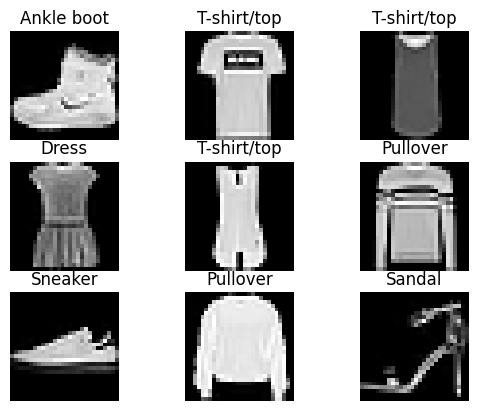

In [29]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(3, 3)
for i, ax in enumerate(axes.flat):
    image, label = training_data[i]
    ax.imshow(image.squeeze(0), cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')
plt.show()

## 3. Model 1: Linear

In [12]:
class FashionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.flatten = nn.Flatten()
    self.linear_layer_1 = nn.Linear(in_features = 784,
                                  out_features = 128)
    self.relu = nn.ReLU()
    self.linear_layer_2 = nn.Linear(in_features = 128,
                                    out_features = 10)

  def forward(self, x):
    return self.linear_layer_2(self.relu(self.linear_layer_1(self.flatten(x))))



In [14]:
model_0 = FashionModel()
model_0.to(device)

FashionModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_layer_1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (linear_layer_2): Linear(in_features=128, out_features=10, bias=True)
)

In [15]:
model_0.state_dict()

OrderedDict([('linear_layer_1.weight',
              tensor([[ 0.0036,  0.0268, -0.0058,  ..., -0.0352, -0.0323,  0.0254],
                      [-0.0332, -0.0095, -0.0216,  ..., -0.0318, -0.0099,  0.0219],
                      [-0.0087,  0.0170,  0.0055,  ...,  0.0294, -0.0231, -0.0187],
                      ...,
                      [ 0.0171, -0.0001,  0.0243,  ..., -0.0238,  0.0248,  0.0057],
                      [ 0.0105,  0.0213, -0.0023,  ..., -0.0342,  0.0293,  0.0174],
                      [ 0.0244,  0.0348, -0.0325,  ..., -0.0100, -0.0268, -0.0283]],
                     device='cuda:0')),
             ('linear_layer_1.bias',
              tensor([-0.0119,  0.0171, -0.0195, -0.0286, -0.0179, -0.0071, -0.0011, -0.0030,
                      -0.0078, -0.0076,  0.0351, -0.0308, -0.0282, -0.0189,  0.0130,  0.0139,
                       0.0168, -0.0101, -0.0056,  0.0184,  0.0314, -0.0337, -0.0313,  0.0330,
                      -0.0261,  0.0273, -0.0257,  0.0248,  0.0232, -0.

Setting up Loss function & Optimzer

In [16]:
# Loss function
loss_fn_0 = nn.CrossEntropyLoss()

# Optimzer
optimizer_0 = torch.optim.SGD(params = model_0.parameters(),
                              lr = 0.1)

In [18]:
loaded_train = DataLoader(dataset = training_data,
                             batch_size = 32,
                             shuffle = True)

loaded_test = DataLoader(dataset = testing_data,
                         batch_size = 32,
                         shuffle = False)
next(model_0.parameters()).device

device(type='cuda', index=0)

### Training & Testing the Linear Model


In [31]:
torch.manual_seed(42)
epochs = 10

for epoch in range(epochs):

  train_acc = 0
  test_acc = 0
  # Setting the model in training mode
  model_0.train()

  # training loop
  # 1. Forward pass
  for X_train, y_train in loaded_train:
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    y_logits_train = model_0(X_train)
    training_preds = torch.argmax(torch.softmax(y_logits_train, dim = 1), dim = 1)

    # 2. loss function/accuracy
    train_loss_0 = loss_fn_0(y_logits_train, y_train)
    train_acc += accuracy_fn(y_true=y_train, y_preds=training_preds)
    # 3. optimzer zero grad
    optimizer_0.zero_grad()

    # 4. Back Propagation
    train_loss_0.backward()

    # 5. optimzer step
    optimizer_0.step()

  # testing loop
  #Setting the model in evaluation mode
  model_0.eval()
  with torch.inference_mode():

    # 1. Forward pass
    for X_test, y_test in loaded_test:
      X_test = X_test.to(device)
      y_test = y_test.to(device)
      y_logits_test = model_0(X_test)
      testing_preds = torch.argmax(torch.softmax(y_logits_test, dim = 1), dim = 1)

      # 2. loss function/accuracy
      test_loss_0 = loss_fn_0(y_logits_test, y_test)
      test_acc += accuracy_fn(y_true=y_test, y_preds=testing_preds)

  # Printing whats happenin'
  if epoch % 1 == 0:
    print(f"Epoch: {epoch} | Training Loss: {train_loss_0:.5f}, Train Accuracy: {train_acc/len(loaded_train):.2f}% | Testing Loss: {test_loss_0}, Test Accuracy: {test_acc/len(loaded_test):.2f}%")

final_train_acc_linear = train_acc / len(loaded_train)
final_test_acc_linear = test_acc / len(loaded_test)

Epoch: 0 | Training Loss: 0.18191, Train Accuracy: 90.25% | Testing Loss: 0.1179649829864502, Test Accuracy: 88.21%
Epoch: 1 | Training Loss: 0.31665, Train Accuracy: 90.58% | Testing Loss: 0.0757051482796669, Test Accuracy: 88.52%
Epoch: 2 | Training Loss: 0.23468, Train Accuracy: 90.72% | Testing Loss: 0.15635919570922852, Test Accuracy: 88.14%
Epoch: 3 | Training Loss: 0.30071, Train Accuracy: 91.03% | Testing Loss: 0.07525987923145294, Test Accuracy: 88.55%
Epoch: 4 | Training Loss: 0.22692, Train Accuracy: 91.27% | Testing Loss: 0.12532052397727966, Test Accuracy: 88.08%
Epoch: 5 | Training Loss: 0.05252, Train Accuracy: 91.41% | Testing Loss: 0.0720677524805069, Test Accuracy: 88.33%
Epoch: 6 | Training Loss: 0.22462, Train Accuracy: 91.69% | Testing Loss: 0.13798294961452484, Test Accuracy: 88.50%
Epoch: 7 | Training Loss: 0.19419, Train Accuracy: 91.84% | Testing Loss: 0.07642817497253418, Test Accuracy: 88.48%
Epoch: 8 | Training Loss: 0.38431, Train Accuracy: 92.03% | Testing

Prediction

In [32]:
with torch.inference_mode():
    for X_test, y_test in testing_data:
        X_test = X_test.to(device)
        preds = model_0(X_test.unsqueeze(0))
        break

In [33]:
linear_probs = torch.softmax(preds, dim=1)
linear_preds = torch.argmax(linear_probs, dim=1)
print(linear_preds)

tensor([9], device='cuda:0')


## 4. Model 2: CNN (Convolutional Neural Network)

In [34]:
class FashionModelCNN(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.cnn_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.cnn_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units*7*7, output_shape)
        )

    def forward(self, x):
      return self.classifier(self.cnn_2(self.cnn_1(x)))


In [23]:
model_1 = FashionModelCNN(input_shape=1,
                          hidden_units=10,
                          output_shape=len(class_names)).to(device)


Setting up Loss function & Optimzer

In [35]:
# Loss function
loss_fn_1 = nn.CrossEntropyLoss()

# Optimzer
optimizer_1 = torch.optim.SGD(params = model_1.parameters(),
                              lr = 0.1)

### Training & Testing the CNN Model


In [36]:
torch.manual_seed(42)
epochs_cnn = 10

for epoch in range(epochs_cnn):

  train_acc_cnn = 0
  test_acc_cnn = 0
  # Setting the model in training mode
  model_1.train()
  # training loop

  # 1. Forward pass
  for X_train, y_train in loaded_train:
    X_train_cnn = X_train.to(device)
    y_train_cnn = y_train.to(device)
    y_logits_train_cnn = model_1(X_train_cnn)
    training_preds_cnn = torch.argmax(torch.softmax(y_logits_train_cnn, dim = 1), dim = 1)

    # 2. loss function/accuracy
    train_loss_1 = loss_fn_1(y_logits_train_cnn, y_train_cnn)
    train_acc_cnn += accuracy_fn(y_true=y_train_cnn, y_preds=training_preds_cnn)

    # 3. optimzer zero grad
    optimizer_1.zero_grad()

    # 4. Back Propagation
    train_loss_1.backward()

    # 5. optimzer step
    optimizer_1.step()

  # testing loop
  model_1.eval()
  with torch.inference_mode():

    # 1. Forward pass
    for X_test, y_test in loaded_test:
      X_test_cnn = X_test.to(device)
      y_test_cnn = y_test.to(device)
      y_logits_test_cnn = model_1(X_test_cnn)
      testing_preds_cnn = torch.argmax(torch.softmax(y_logits_test_cnn, dim = 1), dim = 1)

      # 2. loss function/accuracy
      test_loss_1 = loss_fn_1(y_logits_test_cnn, y_test_cnn)
      test_acc_cnn += accuracy_fn(y_true=y_test_cnn, y_preds=testing_preds_cnn)

  # Printing whats happenin'
  if epoch % 1 == 0:
    print(f"Epoch: {epoch} | Training Loss: {train_loss_1:.5f}, Train Accuracy: {train_acc_cnn/len(loaded_train):.2f}% | Testing Loss: {test_loss_1}, Test Accuracy: {test_acc_cnn/len(loaded_test):.2f}%")

final_train_acc_cnn = train_acc_cnn / len(loaded_train)
final_test_acc_cnn = test_acc_cnn / len(loaded_test)

Epoch: 0 | Training Loss: 0.23755, Train Accuracy: 91.37% | Testing Loss: 0.36973437666893005, Test Accuracy: 90.22%
Epoch: 1 | Training Loss: 0.24879, Train Accuracy: 91.58% | Testing Loss: 0.1156276986002922, Test Accuracy: 90.06%
Epoch: 2 | Training Loss: 0.08144, Train Accuracy: 91.59% | Testing Loss: 0.19499929249286652, Test Accuracy: 90.68%
Epoch: 3 | Training Loss: 0.26140, Train Accuracy: 91.69% | Testing Loss: 0.4459775984287262, Test Accuracy: 90.11%
Epoch: 4 | Training Loss: 0.15385, Train Accuracy: 91.76% | Testing Loss: 0.29088592529296875, Test Accuracy: 90.11%
Epoch: 5 | Training Loss: 0.06749, Train Accuracy: 91.83% | Testing Loss: 0.1841084361076355, Test Accuracy: 89.31%
Epoch: 6 | Training Loss: 0.12585, Train Accuracy: 92.01% | Testing Loss: 0.16404074430465698, Test Accuracy: 90.04%
Epoch: 7 | Training Loss: 0.11862, Train Accuracy: 91.87% | Testing Loss: 0.12245215475559235, Test Accuracy: 90.71%
Epoch: 8 | Training Loss: 0.27873, Train Accuracy: 92.06% | Testing

Prediction

In [37]:
with torch.inference_mode():
    for X_test_cnn, y_test_cnn in testing_data:
        X_test_cnn = X_test_cnn.to(device)
        CNN_logits = model_1(X_test_cnn.unsqueeze(0))
        pred_class_CNN = torch.argmax(CNN_logits, dim=1)
        print(f"Predicted: {class_names[pred_class_CNN.item()]} | Actual: {class_names[y_test_cnn]}")
        break

Predicted: Ankle boot | Actual: Ankle boot


In [38]:
CNN_probs = torch.softmax(CNN_logits, dim=1)
CNN_preds = torch.argmax(CNN_probs, dim=1)
print(CNN_preds)

tensor([9], device='cuda:0')


## 5. Results Comparison

In [39]:
print("=" * 55)
print(f"{'Model':<15} {'Train Acc':>12} {'Test Acc':>12}")
print("=" * 55)
print(f"{'Linear':<15} {final_train_acc_linear:>11.2f}% {final_test_acc_linear:>11.2f}%")
print(f"{'CNN':<15} {final_train_acc_cnn:>11.2f}% {final_test_acc_cnn:>11.2f}%")
print("=" * 55)


Model              Train Acc     Test Acc
Linear                92.08%       88.46%
CNN                   92.06%       90.34%
